In [63]:
import pandas as pd
from nltk.corpus import stopwords
import string
import re
from nltk.tokenize import RegexpTokenizer
import nltk
from sklearn.model_selection import train_test_split


In [64]:
columns = ['target','ids','date','flag','user','text']

df = pd.read_csv("training.1600000.processed.noemoticon.csv",encoding='ISO-8859-1', names=columns)




In [65]:
df.sample(6)


,target,ids,date,flag,user,text
160784,0,1957146502,Thu May 28 23:38:55 PDT 2009,NO_QUERY,annabarclay,big day 2day the xt launch was amazing! so muc...
530731,0,2196041793,Tue Jun 16 11:56:56 PDT 2009,NO_QUERY,juicy_bubblegum,grrr............. my dad is going to take my p...
1053776,4,1961786409,Fri May 29 10:02:35 PDT 2009,NO_QUERY,Fire_flybot,@TFA_Swoop OOC: You're my favourite TFA Dinobot
543641,0,2200840499,Tue Jun 16 19:26:51 PDT 2009,NO_QUERY,anesio,Hate being sick at home...i'm sooooo bored
102097,0,1794785058,Thu May 14 06:33:16 PDT 2009,NO_QUERY,AndreeaBerghea,"phone calls, emails, demanding people, stress,..."
269202,0,1989567922,Mon Jun 01 02:00:59 PDT 2009,NO_QUERY,bella_cullen_4,IRL Im Sure My Family Hate Me. I Feel Soo Lone...


In [66]:
df.isna().sum()

target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64

In [67]:
df['target'].unique()

array([0, 4], dtype=int64)

In [68]:
data=df[['text','target']]


In [69]:
data['target'] = data['target'].replace(4,1)

C:\Users\hwi\AppData\Local\Temp\ipykernel_5672\2499609609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['target'] = data['target'].replace(4,1)


In [70]:
data

,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0
...,...,...
1599995,Just woke up. Having no school is the best fee...,1
1599996,TheWDB.com - Very cool to hear old Walt interv...,1
1599997,Are you ready for your MoJo Makeover? Ask me f...,1
1599998,Happy 38th Birthday to my boo of alll time!!! ...,1


In [71]:
data_p = data[data['target'] == 1]
data_n = data[data['target'] == 0]
data_p = data_p.iloc[:int(20000)]
data_n = data_n.iloc[:int(20000)]
df = pd.concat([data_p, data_n])
df.shape 

(40000, 2)

In [72]:
df['text']=df['text'].str.lower()
df.head()

,text,target
800000,i love @health4uandpets u guys r the best!!,1
800001,im meeting up with one of my besties tonight! ...,1
800002,"@darealsunisakim thanks for the twitter add, s...",1
800003,being sick can be really cheap when it hurts t...,1
800004,@lovesbrooklyn2 he has that effect on everyone,1


In [73]:
stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from',
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're','s', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves']

In [74]:
def remove_stopwords(text):
    new_text = []
    
    for word in text.split():
        if word in stopwords.words('english'):
            new_text.append('')
        else:
            new_text.append(word)
    x = new_text[:]
    new_text.clear()
    return " ".join(x)

In [75]:
df['text'] = df['text'].apply(remove_stopwords)


In [76]:
english_punctuations = string.punctuation
punctuations_list = english_punctuations
def cleaning_punctuations(text):
    translator = str.maketrans('', '', punctuations_list)
    return text.translate(translator)
df['text']= df['text'].apply(lambda x: cleaning_punctuations(x))
df['text'].tail()

19995     much time   weekend work trip  malmï¿½ frisat...
19996                                   one  day  holidays
19997                feeling   right    hate  damn humprey
19998    geezi hv  read  whole book  personality types ...
19999     threw  sign  donnie   bent   get       thinge...
Name: text, dtype: object

In [77]:
df.sample(6)

,text,target
16966,everyones house want sleep,0
810709,polymorphic1 kevinc2003 im gonna give bsg r...,1
804227,planning routine fame auditions,1
9221,im completely drained suppose day drinking that,0
806717,chappy87 hahaha aiming vomitfactor,1
812059,might qualify diet httpbitlyysxem,1


In [78]:
def cleaning_repeating_char(text):
    return re.sub(r'(.)1+', r'1', text)
df['text'] = df['text'].apply(lambda x: cleaning_repeating_char(x))
df['text'].tail()


19995     much time   weekend work trip  malmï¿½ frisat...
19996                                   one  day  holidays
19997                feeling   right    hate  damn humprey
19998    geezi hv  read  whole book  personality types ...
19999     threw  sign  donnie   bent   get       thinge...
Name: text, dtype: object

In [79]:
def cleaning_URLs(data):
    return re.sub('((www.[^s]+)|(https?://[^s]+))',' ',data)
df['text'] = df['text'].apply(lambda x: cleaning_URLs(x))
df['text'].tail()

19995     much time   weekend work trip  malmï¿½ frisat...
19996                                   one  day  holidays
19997                feeling   right    hate  damn humprey
19998    geezi hv  read  whole book  personality types ...
19999     threw  sign  donnie   bent   get       thinge...
Name: text, dtype: object

In [80]:
def cleaning_numbers(data):
    return re.sub('[0-9]+', '', data)
df['text'] = df['text'].apply(lambda x: cleaning_numbers(x))
df['text'].tail()

19995     much time   weekend work trip  malmï¿½ frisat...
19996                                   one  day  holidays
19997                feeling   right    hate  damn humprey
19998    geezi hv  read  whole book  personality types ...
19999     threw  sign  donnie   bent   get       thinge...
Name: text, dtype: object

In [81]:
tokenizer = RegexpTokenizer('\s+', gaps = True)
df['text'] = df['text'].apply(tokenizer.tokenize)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\hwi\AppData\Local\Temp\ipykernel_5672\2193711807.py:1: SyntaxWarning: invalid escape sequence '\s'
  tokenizer = RegexpTokenizer('\s+', gaps = True)


In [82]:
df['text'].tail()


19995    [much, time, weekend, work, trip, malmï¿½, fri...
19996                                 [one, day, holidays]
19997                [feeling, right, hate, damn, humprey]
19998    [geezi, hv, read, whole, book, personality, ty...
19999    [threw, sign, donnie, bent, get, thingee, made...
Name: text, dtype: object

In [83]:
st = nltk.PorterStemmer()
def stemming_on_text(data):
    text = [st.stem(word) for word in data]
    return data
df['text']= df['text'].apply(lambda x: stemming_on_text(x))
df['text'].head()

800000             [love, healthuandpets, u, guys, r, best]
800001    [im, meeting, one, besties, tonight, cant, wai...
800002    [darealsunisakim, thanks, twitter, add, sunisa...
800003    [sick, really, cheap, hurts, much, eat, real, ...
800004                    [lovesbrooklyn, effect, everyone]
Name: text, dtype: object

In [84]:
lm = nltk.WordNetLemmatizer()
def lemmatizer_on_text(data):
    text = [lm.lemmatize(word) for word in data]
    return data
df['text'] = df['text'].apply(lambda x: lemmatizer_on_text(x))
df['text'].head()

800000             [love, healthuandpets, u, guys, r, best]
800001    [im, meeting, one, besties, tonight, cant, wai...
800002    [darealsunisakim, thanks, twitter, add, sunisa...
800003    [sick, really, cheap, hurts, much, eat, real, ...
800004                    [lovesbrooklyn, effect, everyone]
Name: text, dtype: object

In [85]:
df[df['target']==0]['text']


0        [switchfoot, httptwitpiccomzl, a, s, bummer, s...
1        [upset, cant, update, facebook, texting, it, m...
2        [kenichan, dived, many, times, ball, managed, ...
3                  [whole, body, feels, itchy, like, fire]
4        [nationwideclass, no, behaving, all, im, mad, ...
                               ...                        
19995    [much, time, weekend, work, trip, malmï¿½, fri...
19996                                 [one, day, holidays]
19997                [feeling, right, hate, damn, humprey]
19998    [geezi, hv, read, whole, book, personality, ty...
19999    [threw, sign, donnie, bent, get, thingee, made...
Name: text, Length: 20000, dtype: object

(-0.5, 1599.5, 799.5, -0.5)

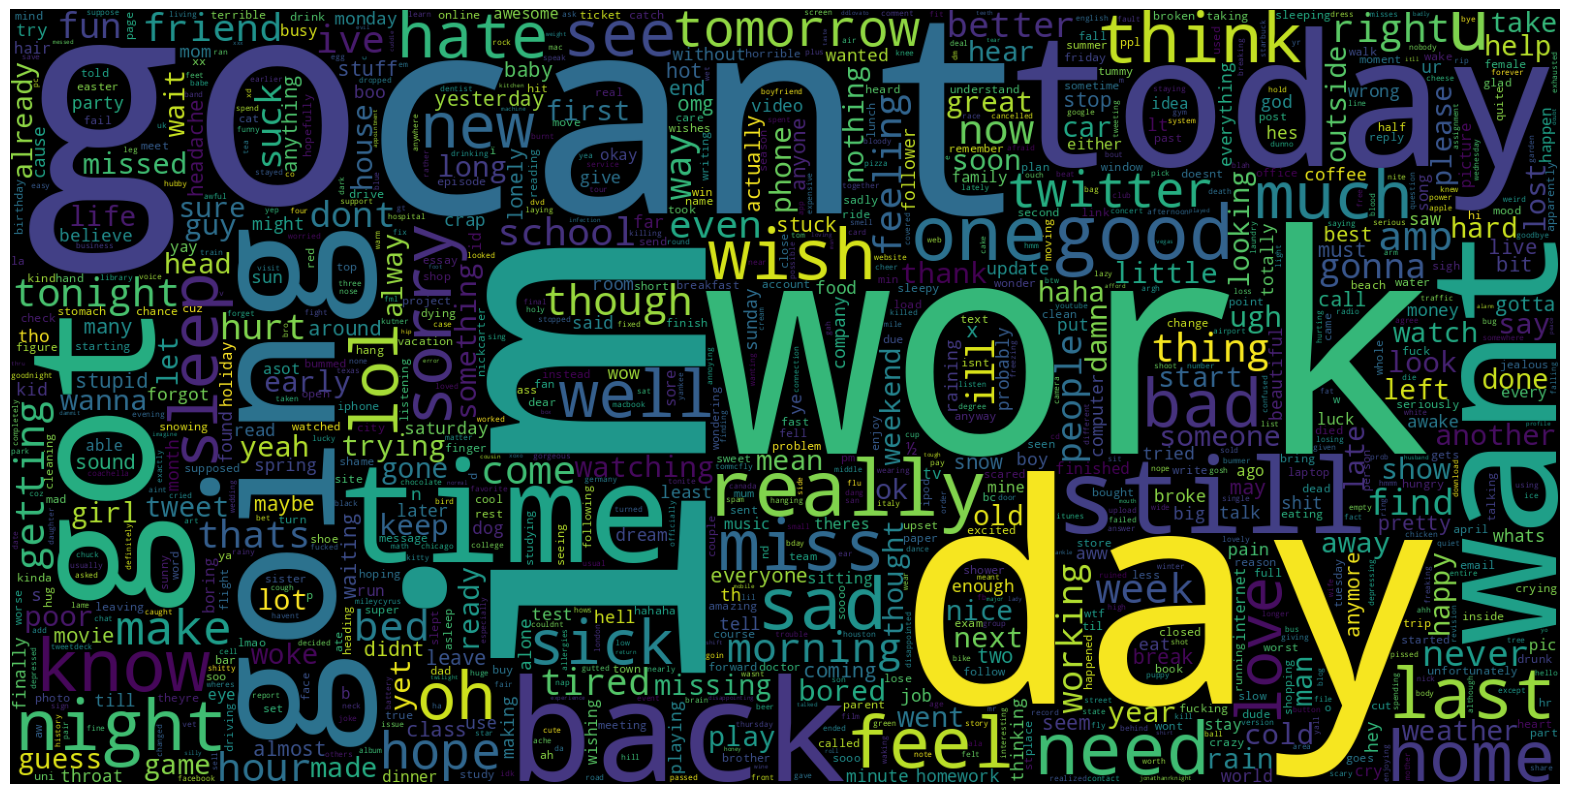

In [86]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
data_neg = df[df['target']==0]['text'].apply(lambda x: ' '.join(x) )
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
               collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)
plt.axis('off')

(-0.5, 1599.5, 799.5, -0.5)

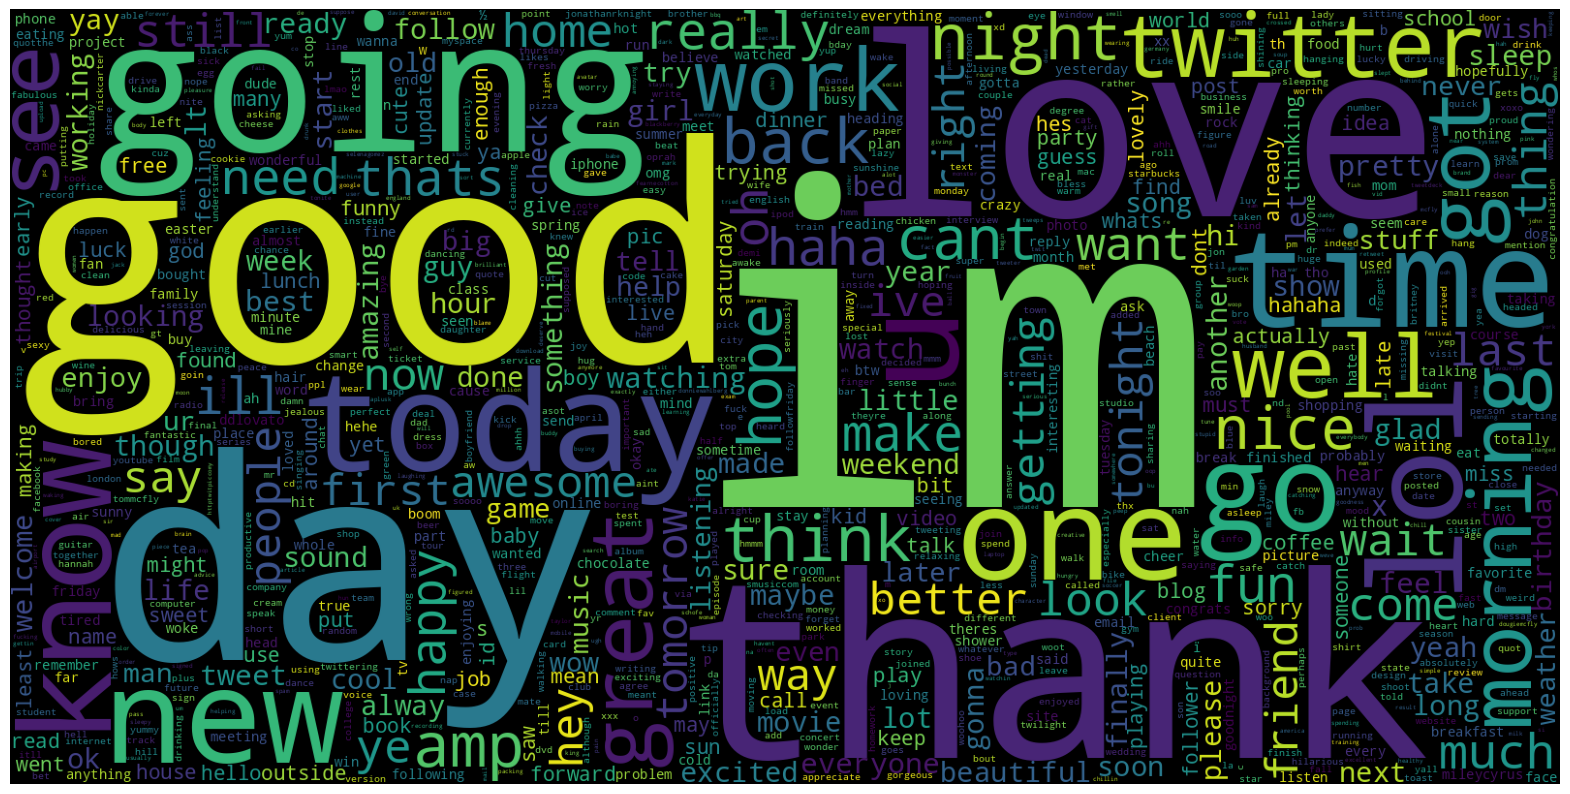

In [87]:
data_neg = df[df['target']==1]['text'].apply(lambda x: ' '.join(x) )
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
               collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)
plt.axis('off')

In [88]:
ndata=df
ndata['text'] = df['text'].apply(lambda x: ' '.join(x) )
ndata.head()

,text,target
800000,love healthuandpets u guys r best,1
800001,im meeting one besties tonight cant wait girl ...,1
800002,darealsunisakim thanks twitter add sunisa got ...,1
800003,sick really cheap hurts much eat real food plu...,1
800004,lovesbrooklyn effect everyone,1


In [89]:
X=ndata.text
y=ndata.target

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.10,
                                                    random_state =0)

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
vectoriser.fit(X_train)
print('No. of feature_words: ', len(vectoriser.get_feature_names_out()))

No. of feature_words:  5000


In [92]:
X_train = vectoriser.transform(X_train)
X_test  = vectoriser.transform(X_test)

In [96]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


In [93]:
from sklearn.svm import SVC
clf=SVC()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [97]:
kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    print(f"\n🔹 Testing kernel: {kernel}")
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {kernel} kernel: {acc:.4f}")
    print(classification_report(y_test, y_pred))



🔹 Testing kernel: linear
Accuracy for linear kernel: 0.7490
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      2003
           1       0.73      0.79      0.76      1997

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000


🔹 Testing kernel: rbf
Accuracy for rbf kernel: 0.7518
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      2003
           1       0.73      0.79      0.76      1997

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000


🔹 Testing kernel: poly
Accuracy for poly kernel: 0.7292
              precision    recall  f1-score   support

           0       0.74      0.71      0.72      2003
           1       0.72      0.75      0.73      1997

    accur

In [94]:
from sklearn.metrics import accuracy_score,confusion_matrix
test_acc=accuracy_score(y_test,y_pred)
print(test_acc)
cfm=confusion_matrix(y_test,y_pred)
print(cfm)

0.75175
[[1427  576]
 [ 417 1580]]


In [104]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import uniform


svc = SVC()


param_dist = {
    'kernel': ['linear', 'rbf', 'poly'],      
    'C': uniform(0.1, 5),                    
    'gamma': uniform(0.01, 0.5)                
}


random_search = RandomizedSearchCV(
    svc,
    param_distributions=param_dist,
    n_iter=5,               
    scoring='accuracy',
    cv=2,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)


y_pred = random_search.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters: {'C': 0.38205789513550126, 'gamma': 0.3709993861334124, 'kernel': 'rbf'}
Best CV Score: 0.7346388888888888
Test Accuracy: 0.74975
              precision    recall  f1-score   support

           0       0.78      0.70      0.74      2003
           1       0.73      0.80      0.76      1997

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000



In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# محاسبه معیارها
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')  # اگر چند کلاسه هست، بنویس average='macro'
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

# نمایش نتایج
print("📊 Evaluation Metrics on Test Set:")
print(f"✅ Accuracy :  {accuracy:.4f}")
print(f"✅ Precision:  {precision:.4f}")
print(f"✅ Recall   :  {recall:.4f}")
print(f"✅ F1-Score :  {f1:.4f}")

# نمایش گزارش کامل
print("\n📝 Classification Report:")
print(classification_report(y_test, y_pred))


📊 Evaluation Metrics on Test Set:
✅ Accuracy :  0.7498
✅ Precision:  0.7253
✅ Recall   :  0.8027
✅ F1-Score :  0.7621

📝 Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.70      0.74      2003
           1       0.73      0.80      0.76      1997

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000



In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])
print(report)


              precision    recall  f1-score   support

    Negative       0.78      0.70      0.74      2003
    Positive       0.73      0.80      0.76      1997

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000

